# Flare Fitting with Bayesian model comparison

This tutorial introduces the flare fitting module for AltaiPony. It models stellar flares using analytic flare shapes from Davenport et al. (2014), combined with a polynomial baseline. The `find_flares()` detection results (`tstart`, `tstop`) are used to define the fitting regions, which are automatically expanded by a small time buffer to ensure full flare coverage. Each region may contain one or more overlapping flares. For each region, the model is optimized for different numbers of flares (1 to `max_flares`) using `emcee`.


**1. Load and Detrend the Light Curve**
   - Load a light curve from TESS or Kepler using `from_mast()`
   - Apply custom detrending (required for `find_flares()`)

**2. Detect Candidate Flares**
   - Detect flares using `find_flares()`
   - This generates an initial table of flare candidates with approximate parameters:
     - `tstart`, `tstop`: start and stop times of each candidate
     - `ampl_rec`, `ed_rec`: rough estimates of flare amplitude and equivalent duration
   - These parameters are later refined in step 4 after model fitting
   - Visually inspect whether the flare windows fully capture each event and exclude unrelated variability

**3. Fit Flares**
   - Fit flare shapes with a composite model (polynomial baseline + analytic flares)
   - Evaluate model quality using BIC
   - Extract posterior uncertainties

**4. Build Summary Table**
   - Use `make_flare_table()` to construct the final flare parameter table from the best-fit models
   - This updates the preliminary `find_flares()` estimates with model-derived values and posterior errors

**5. Inspect Posterior Distributions**
- Use `corner(index)` to plot the posterior distributions for a specific row in the flare table
  - `index` corresponds to the row number (e.g. `0` for the first row)
  - Automatically redirects to the group-level posterior if the row is a `group_member`

In [5]:
import matplotlib.pyplot as plt
from ..altaipony.lcio import from_mast
from altaipony.customdetrend import custom_detrending

ImportError: attempted relative import with no known parent package

## 1. Load and Detrend the Light Curve

We start by downloading a TESS/Kepler (K2 not implemented yet) light curve using the `from_mast()` utility. This returns a `FlareLightCurve` object that is compatible with AltaiPony's flare tools.


## 2. Detect Candidate Flares

We use the built-in flare detection method via the `find_flares()`.

2% (399/18699) of the cadences will be ignored due to the quality mask (quality_bitmask=175).
2% (399/18699) of the cadences will be ignored due to the quality mask (quality_bitmask=175).
/Software/users/modules/9/software/anaconda3/2024.02/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


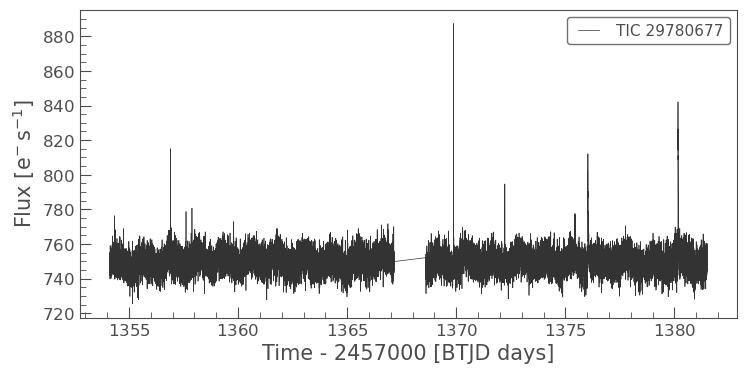

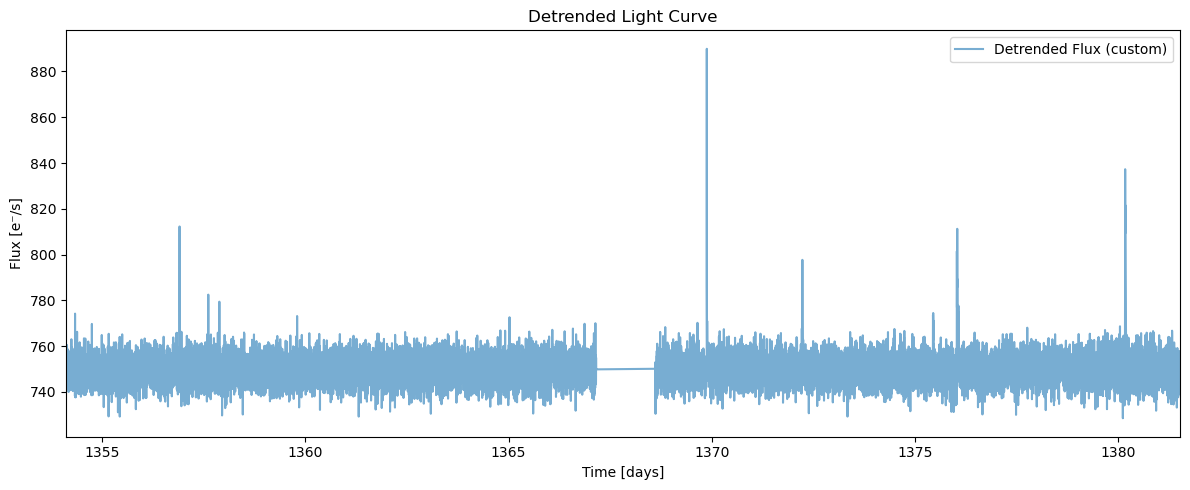

In [2]:
%matplotlib inline
flc = from_mast("TIC 29780677", mode="LC", c=2, cadence="short", mission="TESS", author="SPOC")

flc.plot();
flcd = flc.detrend("custom", func=custom_detrending)

plt.figure(figsize=(12, 5))

plt.plot(flcd.time.value, flcd.detrended_flux, label='Detrended Flux (custom)', alpha=0.6)
plt.xlim(flcd.time.value.min(), flcd.time.value.max())
plt.xlabel("Time [days]")
plt.ylabel("Flux [e⁻/s]")
plt.title("Detrended Light Curve")
plt.legend()
plt.tight_layout()
plt.show() 

In [3]:
flcd = flcd.find_flares()
flcd.flares.sort_values(by="tstart", ascending=True)

Found 0 candidate(s) in the (0,9226) gap.
Found 5 candidate(s) in the (9226,18300) gap.
/net/virgo01/data/users/adanila/Final Project/Git1/AltaiPony/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lc.flares = pd.concat([lc.flares, new], ignore_index=True)


,istart,istop,cstart,cstop,tstart,tstop,ed_rec,ed_rec_err,ampl_rec,dur,total_n_valid_data_points
0,10142,10147,102541,102546,1369.874426,1369.881370,40.217134,1.56003348,0.186941,0.006944,18300.0
1,14075,14078,106547,106550,1375.438284,1375.442450,10.249957,1.58217705,0.031872,0.004167,18300.0
2,14483,14501,106969,106987,1376.024391,1376.049391,120.919968,3.78482181,0.082036,0.025000,18300.0
3,14508,14512,106995,106999,1376.060502,1376.066057,16.200503,1.83411378,0.037186,0.005556,18300.0
4,17372,17388,109949,109965,1380.163246,1380.185468,134.355850,3.7191441,0.116769,0.022222,18300.0


We now have:

1. A **detrended light curve** with reduced stellar variability, which improves flare detection.
2. A set of **high-confidence flare candidates** identified using `find_flares()`.
3. A **preliminary table of flare properties**, including approximate times (`tstart`, `tstop`), amplitudes (`ampl_rec`), and equivalent durations (`ed_rec`, `ed_rec_err`).

These initial estimates will be refined through model fitting in the next step.

## 3. Visualize Detected Flares

After detecting flares with `find_flares()`, it could prove useful to visually inspect whether the detected regions (`tstart`, `tstop`) correctly enclose the flare events and do not include unrelated variability.

We plot the original and detrended light curves, with the flare regions highlighted using red spans. This helps verify that:
- The flare windows fully capture the flare peaks
- No flares were missed due to overly strict thresholds
- The detrending preserved flare morphology

We also zoom in on each individual flare region for detailed inspection.


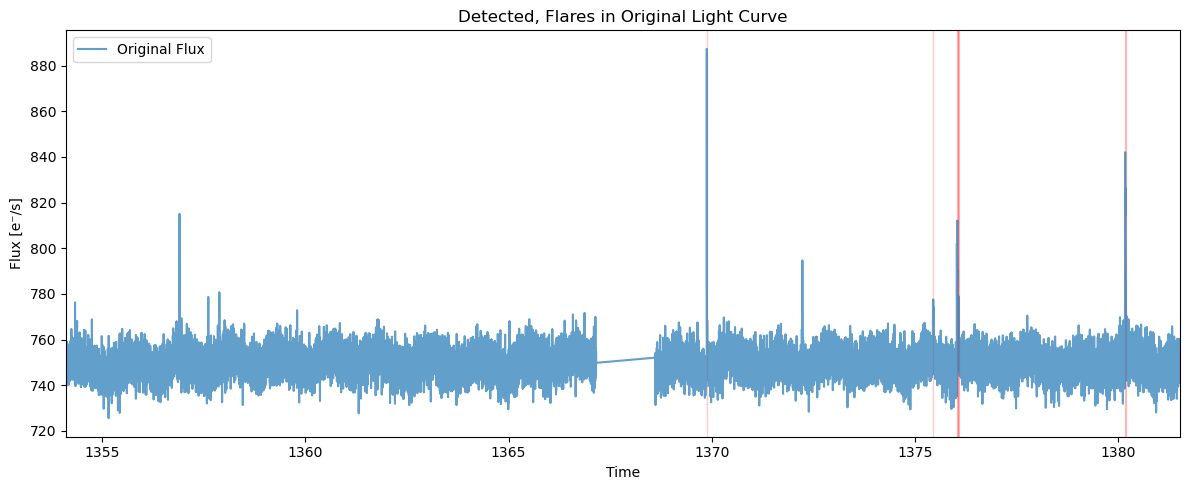

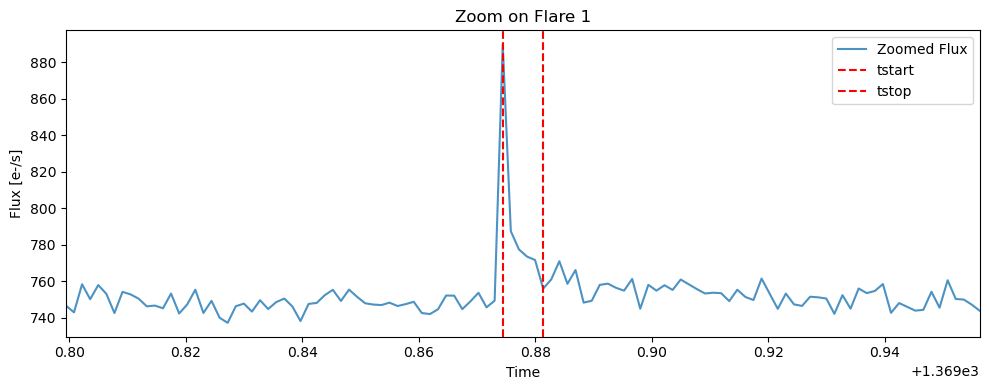

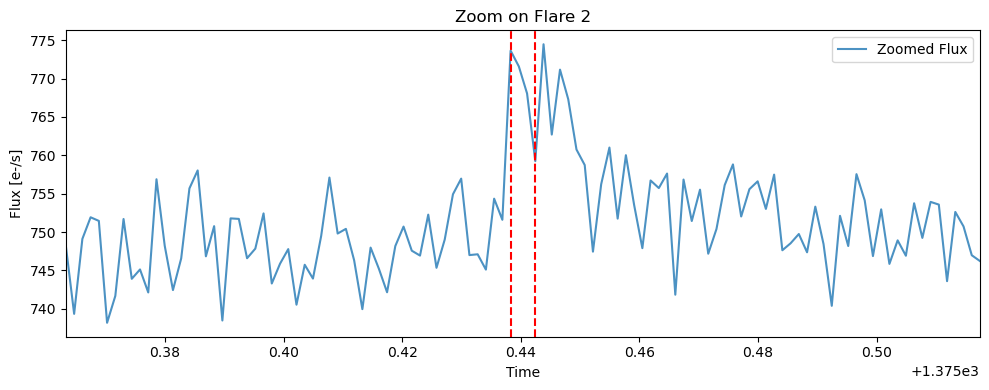

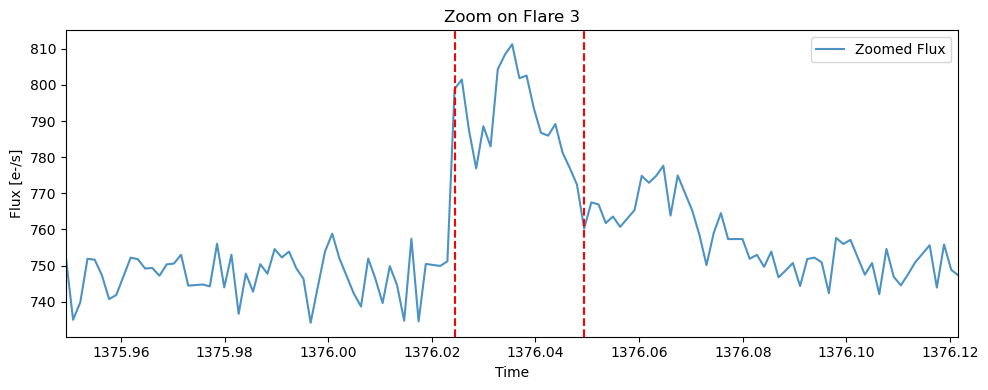

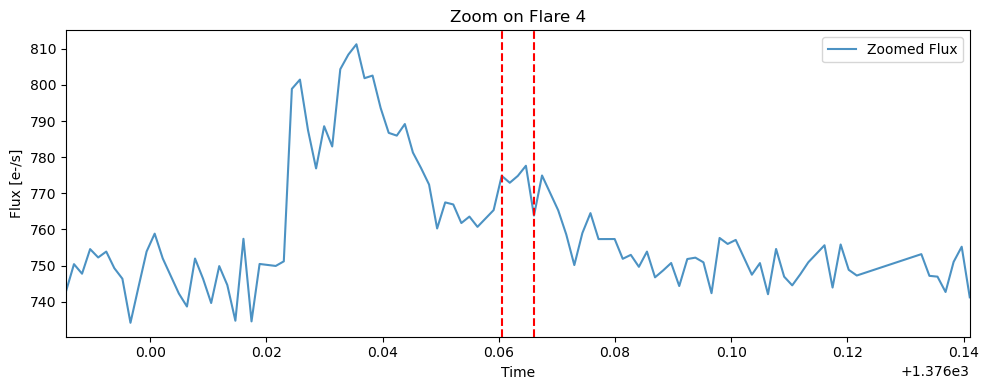

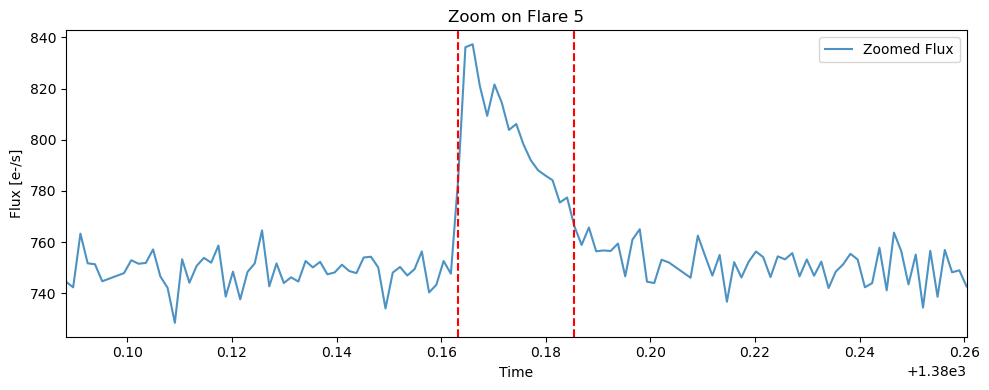

In [ ]:
# Plot light curve with flare regions highlighted
plt.figure(figsize=(12, 5))
plt.plot(flcd.time.value, flc.flux, alpha=0.7)

# Highlight flare windows with translucent red spans
for t1, t2 in flcd.flares[['tstart', 'tstop']].values:
    plt.axvspan(t1, t2, color='red', alpha=0.2)

plt.xlabel("Time [BTJD]")
plt.ylabel("Flux [e⁻/s]")
plt.xlim(flcd.time.value.min(), flcd.time.value.max())
plt.title("Flares in light curve")
plt.legend()
plt.tight_layout()
plt.show()

# Plot zoomed-in views of each detected flare
for i, (t1, t2) in enumerate(flcd.flares[['tstart', 'tstop']].values):
    # Define zoom buffer
    buffer = 0.075
    t_min = t1 - buffer
    t_max = t2 + buffer

    # Select data in zoomed window
    mask = (flcd.time.value >= t_min) & (flcd.time.value <= t_max)
    time_zoom = flcd.time.value[mask]
    flux_zoom = flcd.flux[mask]  # Use flcd.detrended_flux[mask] for detrended version

    # Plot zoomed region
    plt.figure(figsize=(10, 4))
    plt.plot(time_zoom, flux_zoom, alpha=0.8)
    plt.axvline(t1, color='red', linestyle='--', label='tstart' if i == 0 else None)
    plt.axvline(t2, color='red', linestyle='--', label='tstop' if i == 0 else None)
    plt.title(f'Zoom on Flare {i+1}')
    plt.xlim(time_zoom[0], time_zoom[-1])
    plt.xlabel("Time [BTJD]")
    plt.ylabel("Flux [e-/s]")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Fit Flares

We now apply the flare fitting module to the flare regions detected by `find_flares()`. Each region is defined by a ``tstart``-``tstop`` pair, and is automatically expanded by a small time buffer cover the full flare and some quiescent flux. Regions that overlap or occur close together are grouped and fitted simultaneously.

The flare fitting function:
The `fit_flares()` function accepts several user-configurable arguments:

- `buffer`:  
  The time (in days) added before and after each flare detection window. This ensures the flare is not clipped at the edges and allows for a more stable baseline fit. A typical value is `0.05` (i.e., 72 minutes).

- `max_flares`:  
  The maximum number of flare components to attempt fitting in each region. The function will try all models from `n = 1` up to `n = max_flares` and select the best one based on BIC.

- `delta_bic`:  
  Minimum BIC improvement required to accept a more complex model.  
  This helps avoid overfitting by rejecting additional flares that do not significantly improve the fit.  
  **Example:** `delta_bic=2` means a model must improve BIC by at least 2 points to be accepted.

- `plot`:  
  If `True`, plots will be generated during fitting to show the best model per region.  
  **Recommended:** Turn it off when processing large numbers of flares.

- `debug_plot`:  
  If `True`, additional plots are shown for *all attempted models* in each region (e.g., for `n = 1`, `n = 2`, `n = 3`).  
  This is useful for understanding how BIC selects the optimal flare count, and for spotting overfitting or poor fits.  
  **Set to `False`** for normal use or large datasets, as this can produce a large number of plots.
  

 **Note: Detrending vs Fitting Input**

While the `find_flares()` function **requires** a detrended light curve to reliably detect flux enhancements due to flares, the flare fitting module (`fit_flares()`) is best applied to the **original, non-detrended** flux.

This is because detrending methods (e.g., Savitzky-Golay filters) can distort flare shapes by artificially modifying the baseline near flare events.



 Fitting region from 1369.82443 to 1369.93137; Region [0](max_flares = 3)


  0%|          | 0/3000 [00:00<?, ?it/s]/Software/users/modules/9/software/anaconda3/2024.02/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 3000/3000 [00:46<00:00, 64.62it/s]


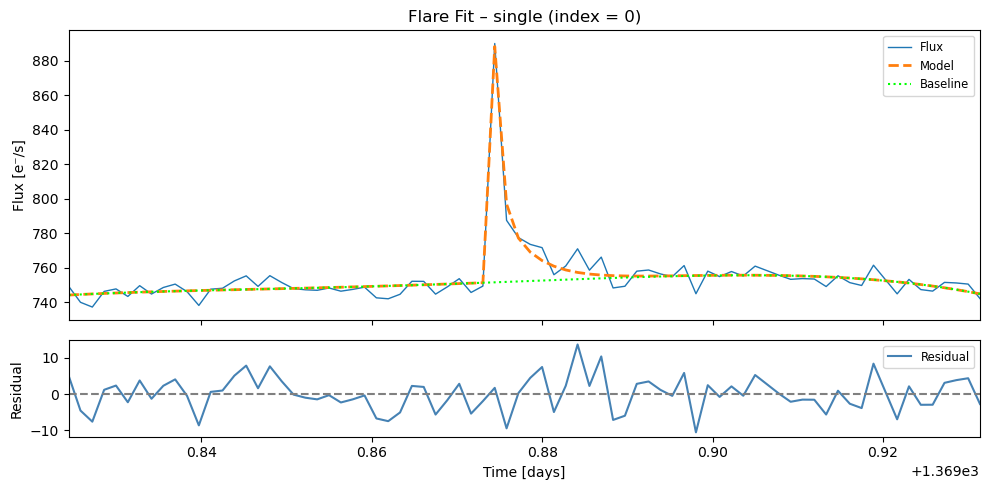


 Fitting region from 1375.38828 to 1375.49245; Region [1](max_flares = 3)


100%|██████████| 3000/3000 [00:41<00:00, 73.02it/s]


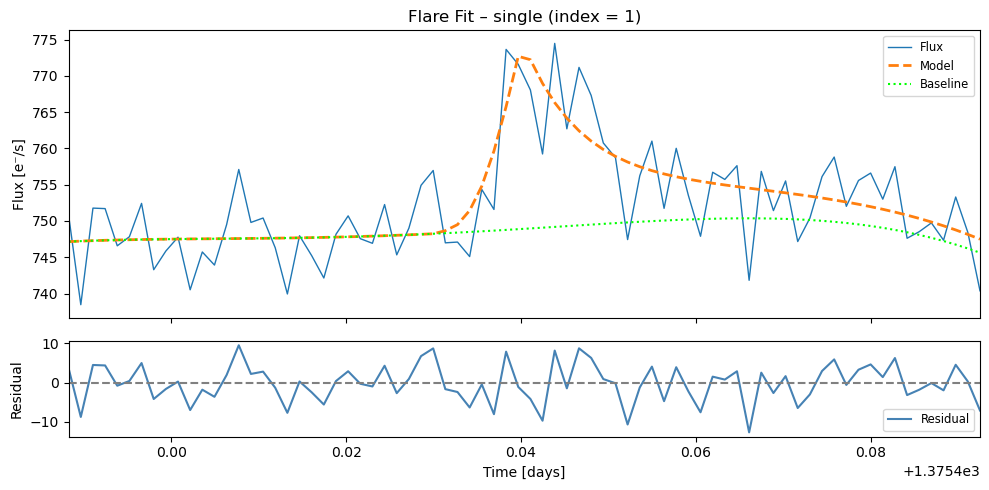


 Fitting region from 1375.97439 to 1376.11606; Region [2](max_flares = 6)


100%|██████████| 3000/3000 [01:05<00:00, 45.47it/s]


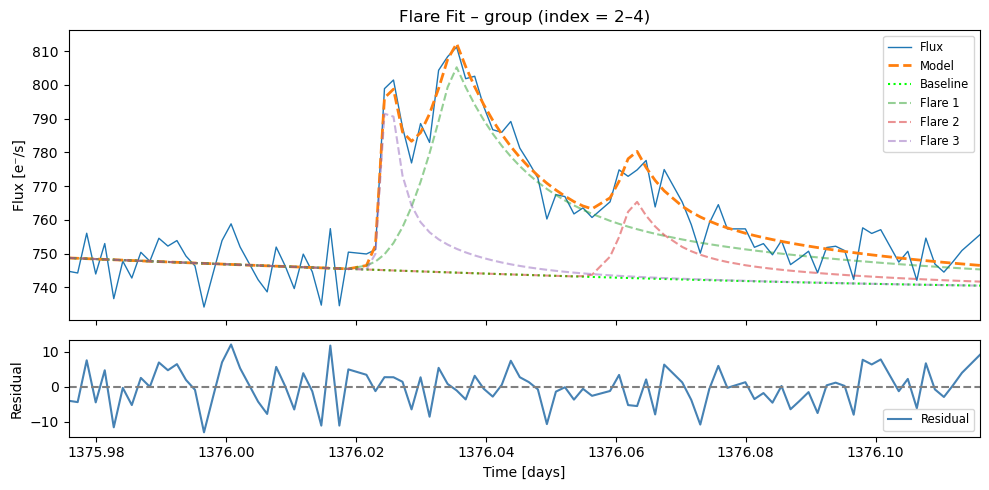


 Fitting region from 1380.11325 to 1380.23547; Region [3](max_flares = 3)


100%|██████████| 3000/3000 [00:57<00:00, 51.99it/s]


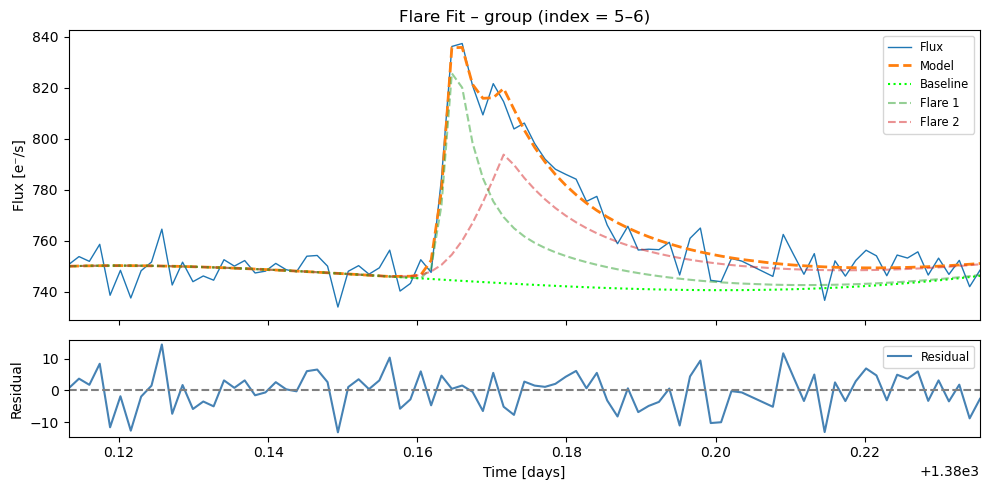

In [ ]:
fit = flcd.fit_flares(
    buffer=0.05,          # Add ±0.05 buffer before/after each flare region for safe margin
    max_flares=3,         # Test models with 1–3 flares per region
    delta_bic=2.0,        # Only accept a more complex model if BIC improves by at least 2 points
    plot=True,            # Plot only the best fit for each region
    debug_plot=False      # Suppress intermediate trial fits (e.g. for n = 1, 2, 3)
)

We compile all results into a summary table that lists the properties of each detected and fitted flare. This is done using `flare_table()`, which extracts key parameters from the results list.


In [ ]:
results = flcd.flare_table(fit)
display(results)

,t_peak,t_peak_err,fwhm,fwhm_err,amplitude,amplitude_err,ed_rec,fit_type,group_index
0,1369.874236,0.000176,0.002145,0.000397,169.168294,35.148752,41.765512,single,
1,1375.440132,0.001119,0.020102,0.014584,26.129508,5.764932,47.371786,single,
2,1376.035175,0.000484,0.032623,0.007751,62.847987,6.415115,184.811468,group_member,1
3,1376.062745,0.001452,0.016152,0.014561,24.686222,16.762984,38.326475,group_member,1
4,1376.024842,0.000182,0.005499,0.002428,67.592668,15.914054,38.986524,group_member,1
5,1380.165041,0.000168,0.008708,0.001504,98.945644,10.173024,90.642198,group_member,2
6,1380.171784,0.000851,0.028435,0.007585,51.803805,7.740229,129.637833,group_member,2


**Notes**

- `ed_rec`: The equivalent duration values in the table are derived from the best-fit analytic flare model, rather than by directly summing the observed flux within the `tstart`-`tstop` detection window. This model-based approach provides more stable estimates that are less sensitive to noise, outliers, or the exact placement of the detection window. However, it also means that the ED values are **dependent on the shape defined by the flare model.**

- `fit_type` indicates the context of the fit:
  - `"single"`: the flare was fit individually (no nearby overlapping events)
  - `"group"`: the combined fit of a group of overlapping flares
  - `"group_member"`: a single flare extracted from a group fit

- `group_index` gives the ID of each flare group (1, 2, 3, ...). All flares sharing the same group index were modeled together. The group row (if present) summarizes the overall multi-flare fit, while the `group_member` rows list the individual flares.


## 5. Inspect Posterior Distributions

The `corner()` function displays the posterior distributions of the flare model parameters for a selected row in the flare table. This helps assess the uncertainty and correlation structure of the fitted values.

To use it, pass the index of the row you want to inspect:

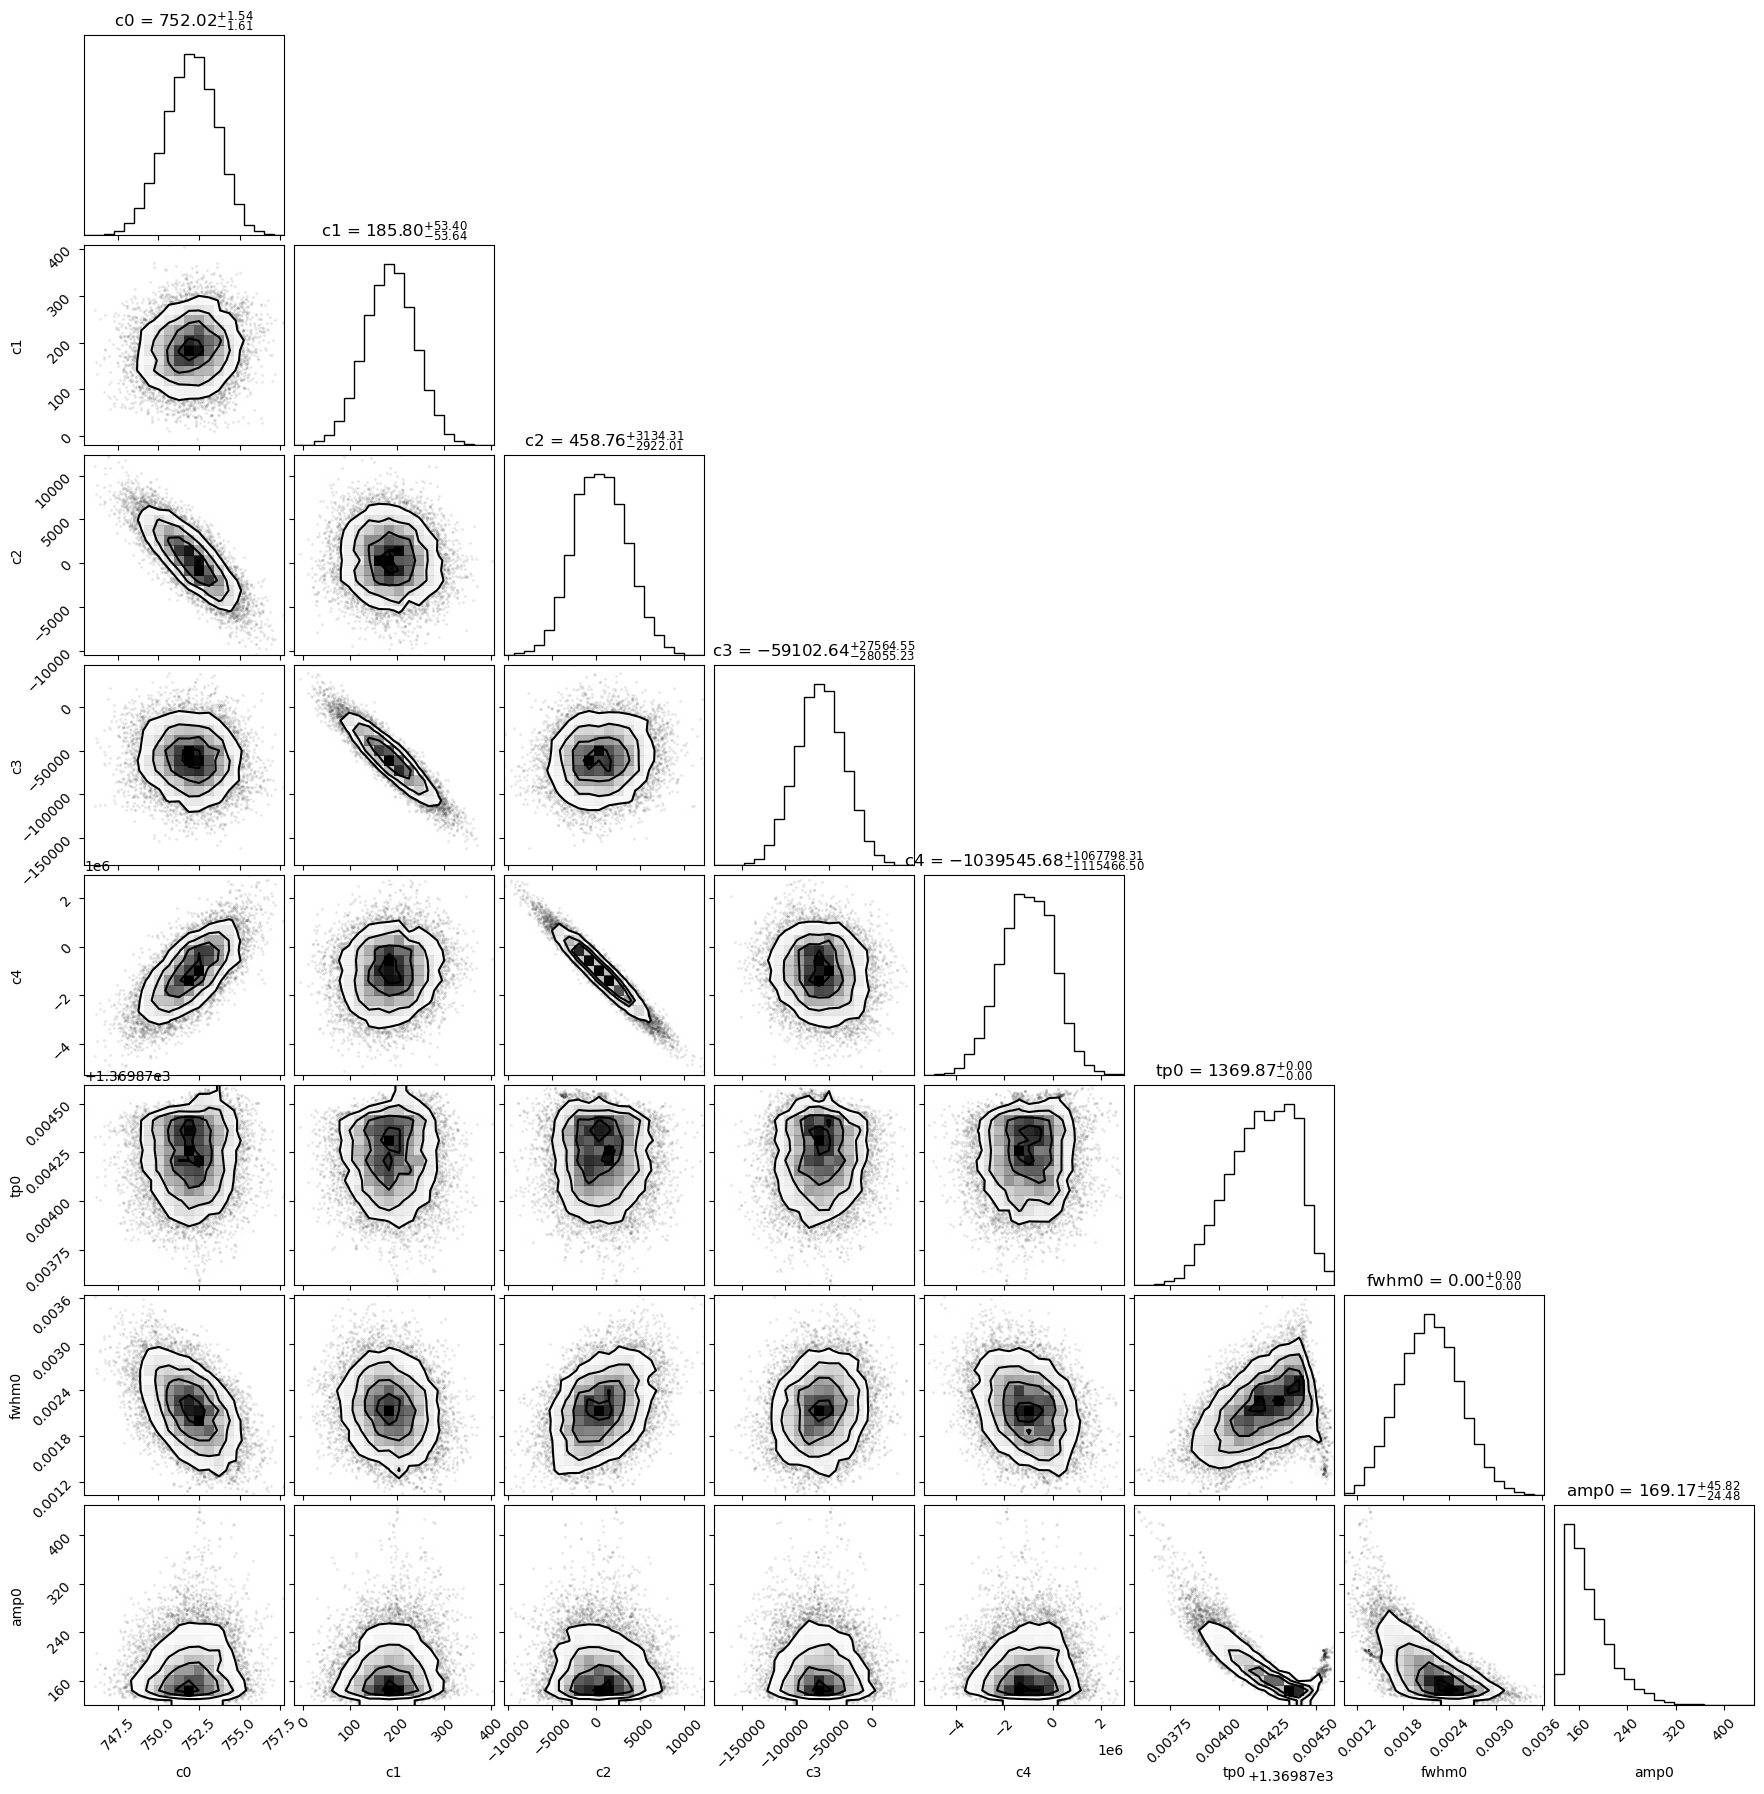

In [7]:
flcd.corner(0)

This shows a corner plot for the flare fit in row 0 of the table. If the selected row corresponds to a `group_member`, the method automatically loads the full posterior from the associated group fit.

The plot includes:

* `c0–c4`: coefficients of the 4th-order baseline polynomial

* `tp{i}`: peak times of each fitted flare

* `fwhm{i}`: flare widths

* `amp{i}`: flare amplitudes

This can be used to verify that parameters are well-constrained and to explore any potential degeneracies between model components.